In [1]:
try:
    import google.colab  # noqa: F401

    %pip install -q dataeval maite-datasets ultralytics
except Exception:
    pass

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from maite_datasets.object_detection import SeaDrone, VOCDetection
from torchvision.transforms.functional import resize
from ultralytics import YOLO

from dataeval.config import set_batch_size
from dataeval.data import Indices, Limit, Select, Shuffle
from dataeval.extractors import ClasswiseUncertaintyExtractor, TorchExtractor, UncertaintyExtractor
from dataeval.shift import DriftWasserstein

# Set default torch device for notebook
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set the default batch size used when loading and encoding images
set_batch_size(32)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
SAMPLES_PER_SPLIT = 200

voc = VOCDetection("./data", year="2012", image_set="train", download=True)

# Three disjoint, exchangeable slices of in-distribution VOC data: two references that
# calibrate the baseline (train, val) and a held-out set that should NOT drift (test).
# Drawing all three from the same pool keeps them statistically interchangeable, so the
# train-vs-val baseline genuinely predicts the train-vs-test distance.
perm = np.random.default_rng(0).permutation(len(voc))
train_idx, val_idx, test_idx = np.array_split(perm[: 3 * SAMPLES_PER_SPLIT], 3)
trainset = Select(voc, Indices(train_idx.tolist()))
valset = Select(voc, Indices(val_idx.tolist()))
testset = Select(voc, Indices(test_idx.tolist()))

# Shifted "operational" data: the SeaDrone maritime aerial (drone-captured) detection dataset
droneset = Select(SeaDrone("./data", image_set="val", download=True), [Shuffle(0), Limit(SAMPLES_PER_SPLIT)])

print(f"train: {len(trainset)}  val: {len(valset)}  test: {len(testset)}  drone: {len(droneset)}")

train: 200  val: 200  test: 200  drone: 200


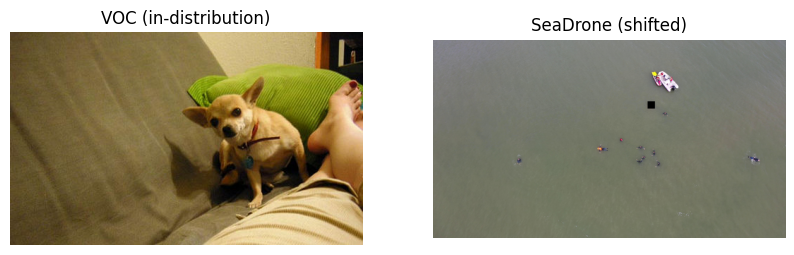

In [4]:
fig, (ax_voc, ax_drone) = plt.subplots(1, 2, figsize=(10, 4))
ax_voc.imshow(np.asarray(trainset[0][0]).transpose(1, 2, 0))
ax_voc.set_title("VOC (in-distribution)")
ax_voc.axis("off")
ax_drone.imshow(np.asarray(droneset[0][0]).transpose(1, 2, 0))
ax_drone.set_title("SeaDrone (shifted)")
ax_drone.axis("off")
plt.show()

In [5]:
def preprocess_fn(image: torch.Tensor) -> torch.Tensor:
    """Prepare a single image for YOLO: resize to 640x640 and scale to [0, 1]."""
    image = resize(image, size=[640, 640])
    return image.float() / 255.0


def postprocess_fn(output: tuple) -> torch.Tensor:
    """Decode YOLOv8 raw output into per-detection class scores.

    YOLOv8's raw output is a ``(inference_tensor, train_output)`` tuple. We take
    the per-anchor class scores, transpose them to ``(batch, anchors, classes)``,
    and keep only anchors with a meaningful detection (max class probability above
    a small floor), yielding a ``(n_detections, n_classes)`` score tensor.
    """
    _, detections = output
    scores = detections["scores"].cpu().mT  # (B, n_classes, n_anchors) -> (B, n_anchors, n_classes)
    max_probs, _ = torch.sigmoid(scores).max(dim=-1)
    keep = max_probs > 0.05  # drop background/empty anchors
    return scores[keep]

In [6]:
# Load the underlying torch module from the Ultralytics wrapper
model = YOLO("data/yolov8s.pt").model

# Decode the detector into per-detection class scores
scores = TorchExtractor(
    model,
    transforms=preprocess_fn,
    postprocess_fn=postprocess_fn,
    device=device,
    batch_size=32,
)

# Per-detection normalized entropy: one uncertainty value per detection
uncertainty = UncertaintyExtractor(scores, preds_type="logits", normalize=True)

In [7]:
h_train = uncertainty(trainset)
h_val = uncertainty(valset)
h_test = uncertainty(testset)
h_drone = uncertainty(droneset)

print(f"detections -> train: {len(h_train)}  val: {len(h_val)}  test: {len(h_test)}  drone: {len(h_drone)}")

detections -> train: 14021  val: 11408  test: 11225  drone: 5613


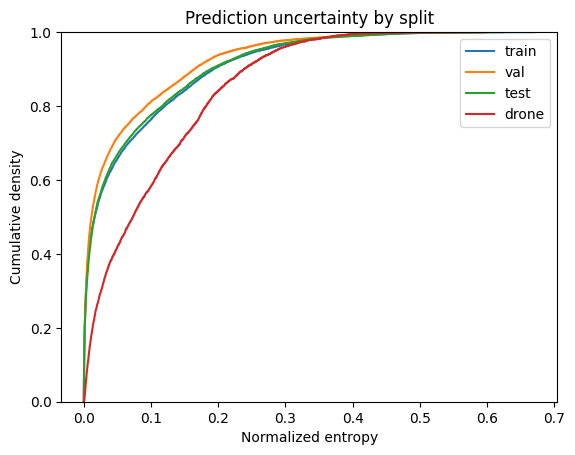

In [8]:
plt.figure()
for label, H in [("train", h_train), ("val", h_val), ("test", h_test), ("drone", h_drone)]:
    plt.ecdf(H.flatten(), label=label)
plt.xlabel("Normalized entropy")
plt.ylabel("Cumulative density")
plt.title("Prediction uncertainty by split")
plt.legend()
plt.show()

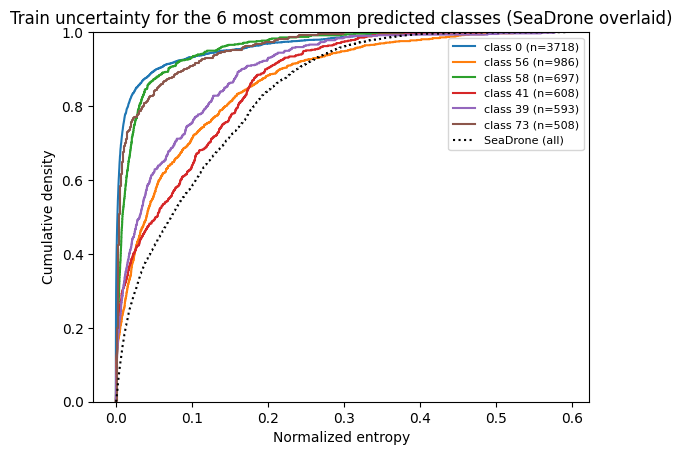

In [9]:
TOP_K_CLASSES = 6

uncertainty_by_class = ClasswiseUncertaintyExtractor(scores, preds_type="logits", normalize=True, threshold=0.99)
Hc_train = uncertainty_by_class(trainset)

# The most frequently predicted classes -- best sampled, so their curves are the most reliable
top_classes = sorted(Hc_train, key=lambda cl: len(Hc_train[cl]), reverse=True)[:TOP_K_CLASSES]

plt.figure()
for cl in top_classes:
    plt.ecdf(Hc_train[cl].flatten(), label=f"class {cl} (n={len(Hc_train[cl])})")
plt.ecdf(h_drone.flatten(), linestyle=":", color="k", label="SeaDrone (all)")
plt.xlabel("Normalized entropy")
plt.ylabel("Cumulative density")
plt.title(f"Train uncertainty for the {TOP_K_CLASSES} most common predicted classes (SeaDrone overlaid)")
plt.legend(fontsize=8)
plt.show()

In [10]:
drift_detector = DriftWasserstein().fit(np.asarray(h_train), np.asarray(h_val))

In [11]:
result_test = drift_detector.predict(np.asarray(h_test))
print(f"VOC held-out -> drift: {result_test.drifted}  (ratio: {result_test.distance:.2f})")

result_drone = drift_detector.predict(np.asarray(h_drone))
print(f"SeaDrone     -> drift: {result_drone.drifted}  (ratio: {result_drone.distance:.2f})")

VOC held-out -> drift: False  (ratio: 0.20)
SeaDrone     -> drift: True  (ratio: 3.43)
